In [1]:
from collections import Counter
import numpy as np
import seaborn as sns
from scipy.stats import spearmanr,pearsonr
import os
from matplotlib import pyplot as plt
import pandas as pd
from scipy import io
from scipy.stats import rankdata

orth = pd.read_csv("../Cell_Type_Prop/Cell_Type_Prop/Orthologs_HumMouseMarm.txt", sep = "\t")
orth = orth[["Gene stable ID", "Gene name", "Mouse gene stable ID", "Mouse gene name", "Mouse homology type"]].dropna().drop_duplicates()
orth1 = orth[orth["Mouse homology type"] == "ortholog_one2one"]
orth1 = orth1.drop_duplicates(["Gene name", "Mouse gene name"])

gene_map1 = dict(
    zip(orth1["Gene name"], orth1["Mouse gene name"])
)
gene_map1["LPHN2"] = "Adgrl2"
gene_map1["LPHN1"] = "Adgrl1"
gene_map1["LPHN3"] = "Adgrl3"
gene_map1["LPHN4"] = "Adgrl4"

hfont = {'fontname':'Arial'}
plt.rcParams["font.family"] = "Arial"

#Code borrowed heavily from here: https://stackoverflow.com/questions/62375034/find-non-overlapping-area-between-two-kde-plots
plt.rcParams.update(
    {"text.usetex": False}
)


In [2]:
vx = pd.read_csv("../PosSelect_ForPub/ProtVar_HumChp_ClosestDomain.prot.stability.ToFix.bed", sep = "\t", header = None).set_index(3)


In [48]:
v = pd.read_csv('HumChp_Mis_Final_Tri447.bed', sep = "\t", header = None)
v.index = v[0] + ":" + v[2].astype(str)
v["Position"] = v.index
v = v[["Position", 3, 5, 6, 7, 8, 11]]
v.columns = ["Position", "Gene", "PhyloP447", "SpecSup447", "PhastCons", "AminoAcidChange", "AncTri"]
vx = vx[vx[6] != -1]
v = v.join(vx).dropna(subset = 18)

v = v[v[18] != "."]

wrong = 0
right = 0
new_v = []
for index, row in v.iterrows():
    chp = row["AminoAcidChange"].split("/")[1]
    hum = row["AminoAcidChange"].split("/")[0]
    if hum == row[13]:
        right += 1
        if chp == row[14]:
            new_v.append(row)
    elif hum == row[14]:
        wrong += 1
print(wrong, right)
v = pd.DataFrame(new_v).sample(frac = 1, replace = False).drop_duplicates("Position")
v[18] = v[18].astype(float)

792 152820


In [49]:
from scipy.stats import ttest_ind,fisher_exact
v = v[v["PhyloP447"] != "."]
v["PhyloP447"] = v["PhyloP447"].astype(float)
ttest_ind(v[v["PhyloP447"] > 5][18], v[v["PhyloP447"] < 1][18])

TtestResult(statistic=np.float64(6.422966689800005), pvalue=np.float64(1.503755233976206e-10), df=np.float64(3753.0))

In [125]:
bins = [(0, 3), (3, 6), (6, 9), (9, 12)]
out = []
for b in bins:

    v_cons = v[(v["PhyloP447"].astype(float) > b[0]) & (v["PhyloP447"] < b[1])]
    v_ncons = v[v["PhyloP447"].astype(float) < 0]
    cons_stab = v_cons[v_cons[18] > 2].shape[0]
    cons_nstab = v_cons[v_cons[18] < 0].shape[0]
    
    ncons_stab = v_ncons[v_ncons[18] > 2].shape[0]
    ncons_nstab = v_ncons[v_ncons[18] < 0].shape[0]
    out.append([str(b[0]) + "-" + str(b[1]), fisher_exact([[cons_stab, cons_nstab], [ncons_stab, ncons_nstab]])[0], fisher_exact([[cons_stab, cons_nstab], [ncons_stab, ncons_nstab]])[1], cons_stab, cons_nstab, ncons_stab, ncons_nstab])

In [137]:
df = pd.DataFrame(out)
df.columns = ["PhyloP bin", "Odds ratio", "p-value", "Conserved destabilizing", "Conserved non-destabilizing", "Unconserved destabilizing", "Unconserved non-destabilizing"]
df

,PhyloP bin,Odds ratio,p-value,Conserved destabilizing,Conserved non-destabilizing,Unconserved destabilizing,Unconserved non-destabilizing
0,0-3,1.187872,0.380503,90,725,58,555
1,3-6,1.845982,0.004280,49,254,58,555
2,6-9,2.672414,0.000130,31,111,58,555
3,9-12,6.043557,0.000029,12,19,58,555


In [138]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact

# Assume your dataframe is called df
# Columns:
# "Conserved destabilizing", "Conserved non-destabilizing",
# "Unconserved destabilizing", "Unconserved non-destabilizing",
# "PhyloP bin"

def compute_fisher_ci(row):
    a = row["Conserved destabilizing"]
    b = row["Conserved non-destabilizing"]
    c = row["Unconserved destabilizing"]
    d = row["Unconserved non-destabilizing"]
    
    # Fisher's exact test
    table = [[a, b], [c, d]]
    oddsratio, pvalue = fisher_exact(table)
    
    # Compute 95% CI using log(OR) approximation
    # Add small pseudocount if zeros present
    if 0 in [a, b, c, d]:
        a, b, c, d = a+0.5, b+0.5, c+0.5, d+0.5
    
    log_or = np.log((a*d)/(b*c))
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    
    ci_low = np.exp(log_or - 1.96 * se)
    ci_high = np.exp(log_or + 1.96 * se)
    
    return pd.Series({
        "odds_ratio": oddsratio,
        "p_value": pvalue,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

# Apply row-wise
results = df.apply(compute_fisher_ci, axis=1)

# Merge back
df = pd.concat([df, results], axis=1)
df["odds_ratio"] = np.log2(df["odds_ratio"])
df["ci_low"] = np.log2(df["ci_low"])
df["ci_high"] = np.log2(df["ci_high"])

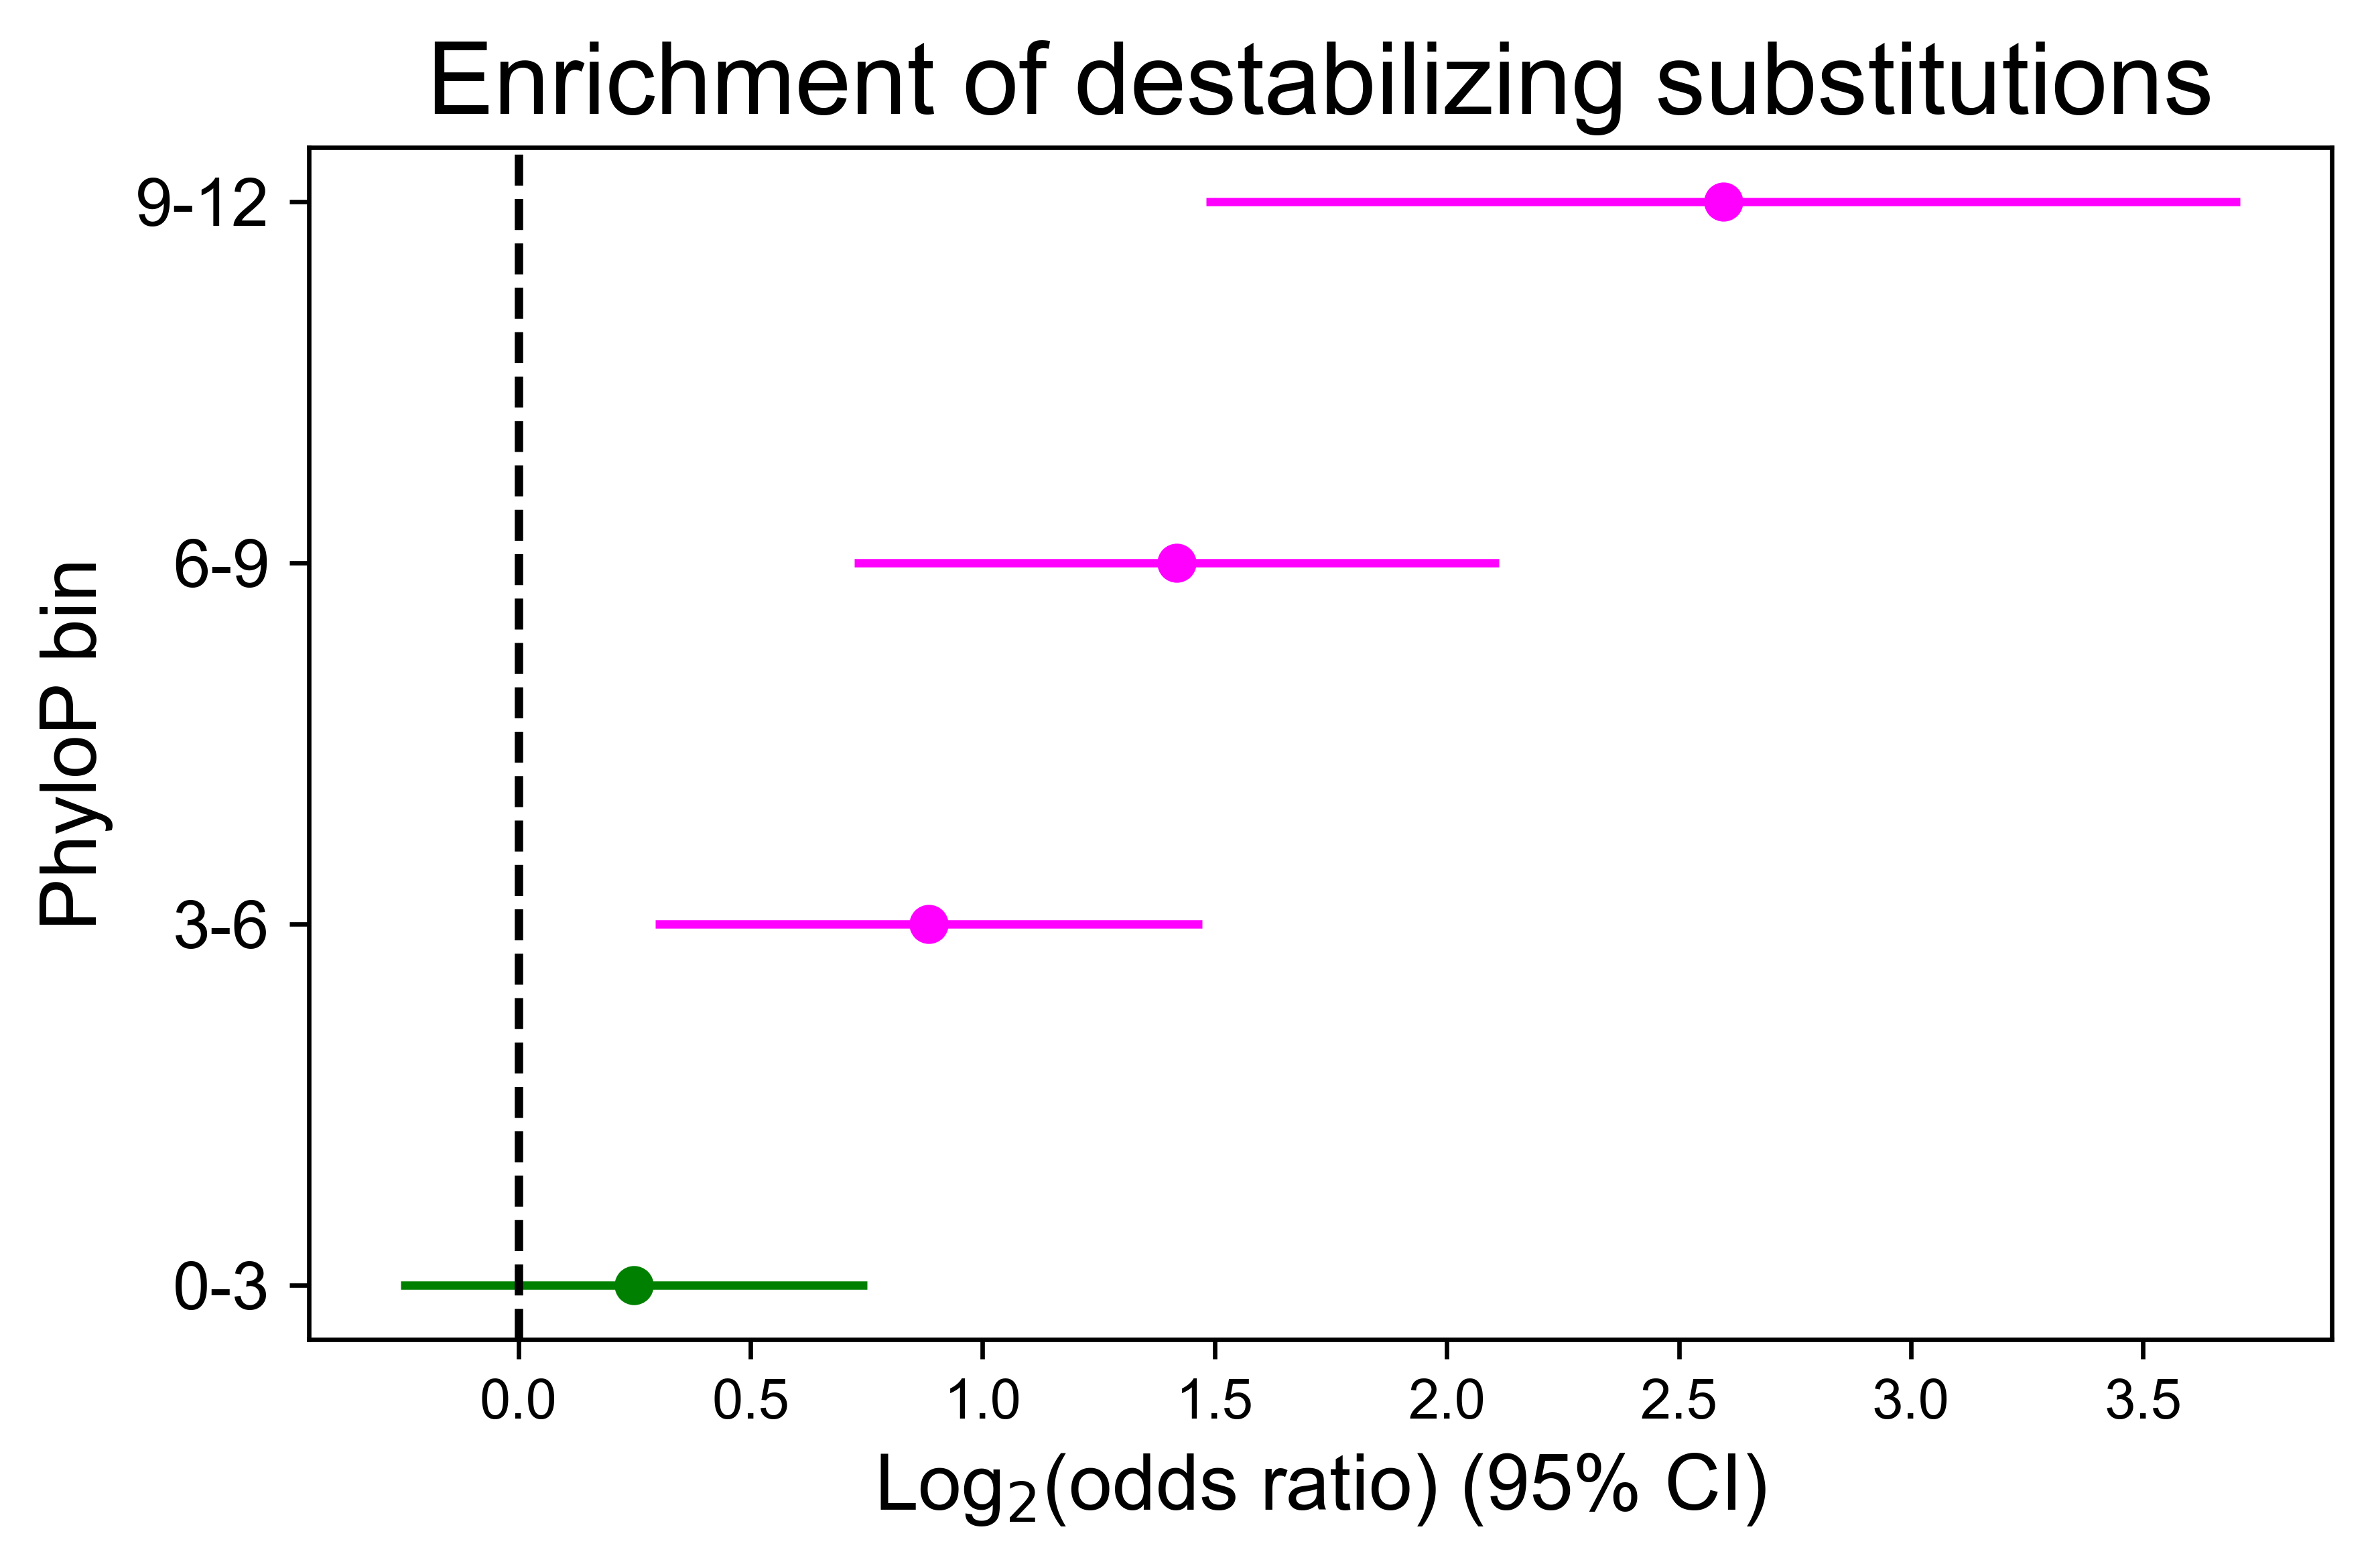

In [146]:
df["color"] = np.where(df["p_value"] < 0.05, "magenta", "green")

import matplotlib.pyplot as plt

# Sort if desired (optional)
y_pos = np.arange(len(df))

plt.figure(figsize=(6, 4), dpi = 600)

for i, row in df.iterrows():
    plt.errorbar(
        x=row["odds_ratio"],
        y=i,
        xerr=[[row["odds_ratio"] - row["ci_low"]],
              [row["ci_high"] - row["odds_ratio"]]],
        fmt='o',
        color=row["color"],
        capsize=0
    )

# Vertical line at OR = 1 (no effect)
plt.axvline(0, linestyle='--', color = "black")

plt.yticks(y_pos, df["PhyloP bin"], size = 12)
plt.xlabel("Log$_{2}$(odds ratio) (95% CI)",size = 14)
plt.title("Enrichment of destabilizing substitutions", size = 18)
plt.ylabel("PhyloP bin", size = 14)

plt.tight_layout()
plt.show()